# Chapter 7. Asymptotic Theory of Statistical Inference

Source orientation: printed pages 165-177, PDF pages 173-185 of *Information Geometry and Its Applications*.

This notebook is a standalone computational reading of the chapter. The guiding question is: when data become a small cloud around the true distribution, what geometric features decide whether an estimator uses that cloud as efficiently as possible?

The visual thread has four stops:

1. The maximum likelihood estimate in an exponential family is the observed sufficient statistic, seen as a projection in expectation coordinates.
2. A curved exponential family is a submanifold inside a larger flat family, so the observed point usually misses the model and must be mapped back.
3. Every consistent estimator determines ancillary fibers, the sets of ambient observations that map to the same estimate.
4. First-order Fisher efficiency is the special case where those fibers meet the model orthogonally; higher-order differences are curvature effects.

No source text is copied here. The formulas are used as orientation for fresh prose, code, and visual checks.


## Setup

Generated files are stored below `artifacts/chapter-07/`. The setup cell discovers the course root from wherever the notebook is executed, then keeps all paths book-local.


In [1]:
from pathlib import Path
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import plotly.graph_objects as go
from IPython.display import display, Image, HTML, Markdown


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
            return candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if candidate.name == 'Information-Geometry-and-Its-Applications':
            return candidate
    raise RuntimeError('Could not locate Information-Geometry-and-Its-Applications root')

BOOK_ROOT = find_book_root()
os.chdir(BOOK_ROOT)
ARTIFACT_DIR = Path('artifacts/chapter-07')
FIG_DIR = ARTIFACT_DIR / 'figures'
HTML_DIR = ARTIFACT_DIR / 'html'
TABLE_DIR = ARTIFACT_DIR / 'tables'
CHECK_DIR = ARTIFACT_DIR / 'checks'
for folder in [FIG_DIR, HTML_DIR, TABLE_DIR, CHECK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260501)
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
})


def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.close()
    return path


def display_artifact(path, kind=None):
    path = Path(path)
    rel = path.as_posix()
    if kind == 'html' or path.suffix.lower() == '.html':
        display(HTML(f'<a href="{rel}" target="_blank">Open interactive artifact: {path.name}</a>'))
    elif path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
        display(Image(filename=str(path)))
    elif path.suffix.lower() == '.csv':
        display(pd.read_csv(path))
    elif path.suffix.lower() == '.json':
        display(Markdown(f'`{rel}`'))
    else:
        display(Markdown(f'`{rel}`'))


## 1. Translation Guide: Asymptotics as Local Geometry

A parametric model is a surface of probability distributions. An estimator reads a sample and returns a point on that surface. For large sample size `N`, the observed sufficient statistic fluctuates at scale `1/sqrt(N)`, so the model can be studied through its tangent space plus the first few curvature corrections.

The chapter uses several coordinate systems at once:

| Statistical phrase | Geometric translation | Computational handle |
| --- | --- | --- |
| observed sufficient statistic | random point in the ambient exponential family | sample mean in expectation coordinates |
| MLE in a full exponential family | the observed point itself | solve `eta(theta) = xbar` |
| curved exponential family | submanifold `S` embedded in a flat family `M` | a curve or surface `eta(u)` inside ambient coordinates |
| estimator on a curved family | map from ambient observations back to `S` | projection or fiber coordinate `u_hat = f(eta_bar)` |
| ancillary family | fibers of equal estimate | curves/surfaces crossing `S` |
| Fisher efficiency | first-order covariance reaches the Cramer-Rao lower bound | fibers orthogonal to `S` in Fisher metric |
| second-order efficiency | compare the next covariance term | curvature of `S` and curvature of the ancillary fibers |

The code below starts with a full exponential family, then intentionally bends the model so that projection and ancillary fibers become visible.


In [2]:
translation_rows = [
    {'chapter object': 'full exponential family', 'local picture': 'flat ambient manifold', 'estimation rule': 'match expectation coordinates to the observed sufficient statistic'},
    {'chapter object': 'curved exponential family', 'local picture': 'submanifold S inside M', 'estimation rule': 'map the observed ambient point back to S'},
    {'chapter object': 'ancillary fiber A(u)', 'local picture': 'all observations assigned the same u', 'estimation rule': 'read the u-coordinate of the crossing fiber'},
    {'chapter object': 'efficient estimator', 'local picture': 'fiber orthogonal to S', 'estimation rule': 'remove all first-order noise normal to S'},
    {'chapter object': 'higher-order comparison', 'local picture': 'curvature terms after tangent approximation', 'estimation rule': 'bias-correct, then compare curvature of model and fibers'},
]
translation_table = pd.DataFrame(translation_rows)
translation_path = TABLE_DIR / 'asymptotic_geometry_translation.csv'
translation_table.to_csv(translation_path, index=False)
display_artifact(translation_path)


,chapter object,local picture,estimation rule
0,full exponential family,flat ambient manifold,match expectation coordinates to the observed ...
1,curved exponential family,submanifold S inside M,map the observed ambient point back to S
2,ancillary fiber A(u),all observations assigned the same u,read the u-coordinate of the crossing fiber
3,efficient estimator,fiber orthogonal to S,remove all first-order noise normal to S
4,higher-order comparison,curvature terms after tangent approximation,"bias-correct, then compare curvature of model ..."


## 2. Full Exponential Family: The MLE Is the Observed Point

In a full exponential family, the sample mean of the sufficient statistic is an expectation-coordinate point. If the true expectation coordinate is `eta`, the observed point `eta_bar` has covariance approximately `G^{-1}/N`. The MLE is obtained by matching the model expectation to this observed point, so in `eta`-coordinates there is no geometric detour: the estimator is just the observed point.

The next figure uses a two-dimensional sufficient statistic. The ellipse shrinks like `1/sqrt(N)`, which is the visual form of the first-order Cramer-Rao rate.


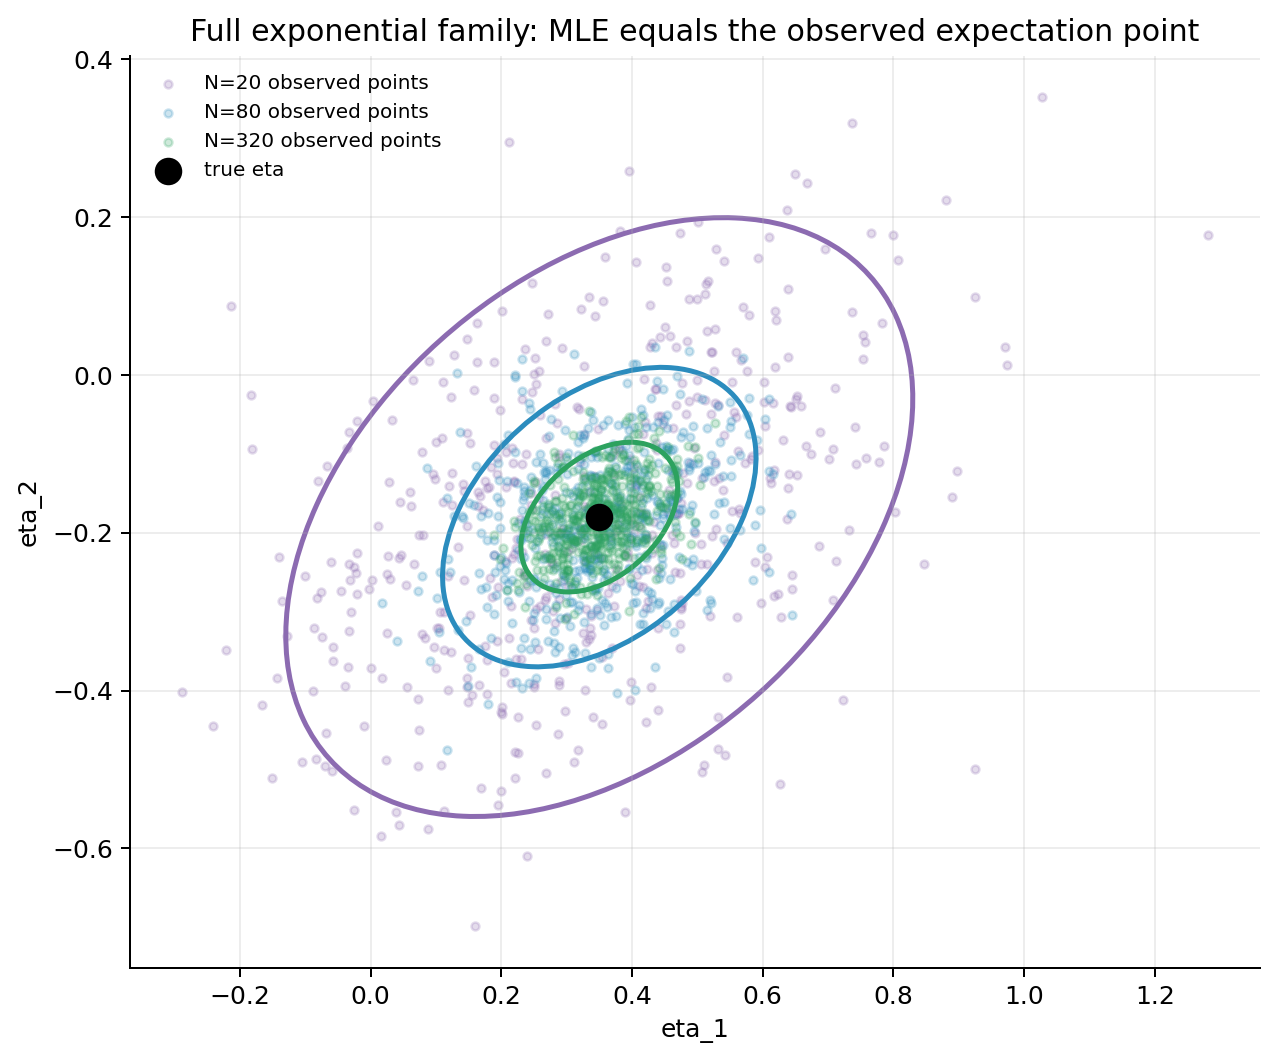

In [3]:
eta_true = np.array([0.35, -0.18])
G_inv = np.array([[1.15, 0.36], [0.36, 0.72]])
Ns = [20, 80, 320]
colors = ['#8c6bb1', '#2b8cbe', '#2ca25f']
fig, ax = plt.subplots(figsize=(7.2, 6.0))
for N, color in zip(Ns, colors):
    samples = rng.multivariate_normal(eta_true, G_inv / N, size=500)
    ax.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.23, color=color, label=f'N={N} observed points')
    vals, vecs = np.linalg.eigh(G_inv / N)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = math.degrees(math.atan2(vecs[1, 0], vecs[0, 0]))
    ellipse = Ellipse(eta_true, width=4*np.sqrt(vals[0]), height=4*np.sqrt(vals[1]), angle=angle,
                      fill=False, lw=2.0, color=color)
    ax.add_patch(ellipse)
ax.scatter([eta_true[0]], [eta_true[1]], s=100, color='black', zorder=4, label='true eta')
ax.set_title('Full exponential family: MLE equals the observed expectation point')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.legend(frameon=False, fontsize=8, ncol=1)
projection_cloud_path = FIG_DIR / 'mle_observed_point_cloud.png'
savefig(projection_cloud_path)
display_artifact(projection_cloud_path)


## 3. Curved Exponential Family: The Observed Point Usually Misses the Model

A curved exponential family is written as a lower-dimensional path or surface inside a larger exponential family. The ambient observed point still comes from the sufficient statistic, but it is not forced to lie on the curved model. An estimator must therefore choose a rule for returning to the model.

The maximum likelihood rule is the information-geometric projection. In the local first-order picture drawn here, the Fisher metric is represented by the Euclidean dot product, so the MLE projection drops the observed point onto the curve along the normal direction.


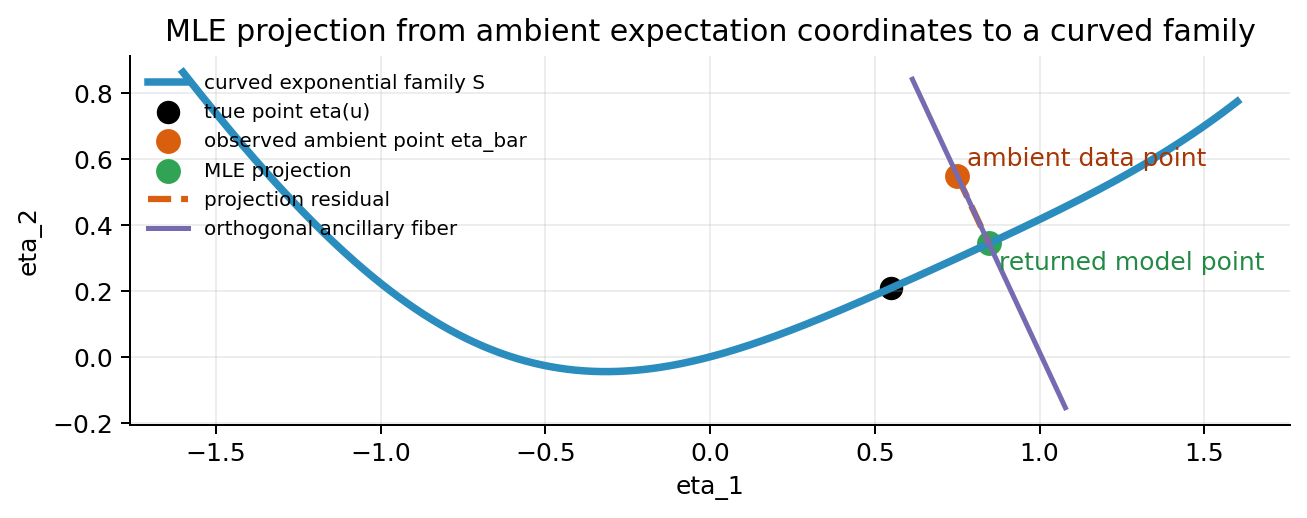

In [4]:
def eta_curve(u):
    u = np.asarray(u, dtype=float)
    return np.column_stack([u, 0.32*u**2 + 0.12*np.sin(2.2*u)]) if u.ndim else np.array([u, 0.32*u**2 + 0.12*np.sin(2.2*u)])

def tangent(u):
    return np.array([1.0, 0.64*u + 0.264*np.cos(2.2*u)])

def unit_normal(u):
    t = tangent(u)
    n = np.array([-t[1], t[0]])
    return n / np.linalg.norm(n)

def project_to_curve(point, grid=None):
    if grid is None:
        grid = np.linspace(-1.8, 1.8, 2401)
    pts = eta_curve(grid)
    d2 = np.sum((pts - point)**2, axis=1)
    k = int(np.argmin(d2))
    return float(grid[k]), pts[k], float(d2[k])

u_true = 0.55
eta_on_model = eta_curve(u_true)
observed_point = eta_on_model + np.array([0.20, 0.34])
u_mle, eta_mle, residual2 = project_to_curve(observed_point)
curve_u = np.linspace(-1.6, 1.6, 500)
curve_pts = eta_curve(curve_u)

fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.plot(curve_pts[:, 0], curve_pts[:, 1], color='#2b8cbe', lw=3, label='curved exponential family S')
ax.scatter([eta_on_model[0]], [eta_on_model[1]], color='black', s=70, label='true point eta(u)')
ax.scatter([observed_point[0]], [observed_point[1]], color='#d95f0e', s=80, label='observed ambient point eta_bar')
ax.scatter([eta_mle[0]], [eta_mle[1]], color='#31a354', s=80, label='MLE projection')
ax.plot([observed_point[0], eta_mle[0]], [observed_point[1], eta_mle[1]], color='#d95f0e', lw=2.5, ls='--', label='projection residual')
normal = unit_normal(u_mle)
fiber = np.array([eta_mle - 0.55*normal, eta_mle + 0.55*normal])
ax.plot(fiber[:, 0], fiber[:, 1], color='#756bb1', lw=2.0, label='orthogonal ancillary fiber')
ax.annotate('ambient data point', observed_point + np.array([0.03, 0.03]), color='#a63603')
ax.annotate('returned model point', eta_mle + np.array([0.03, -0.08]), color='#238b45')
ax.set_title('MLE projection from ambient expectation coordinates to a curved family')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False, fontsize=8, loc='upper left')
curved_projection_path = FIG_DIR / 'curved_family_mle_projection.png'
savefig(curved_projection_path)
display_artifact(curved_projection_path)


## 4. Ancillary Fibers: An Estimator Is a Foliation Near the Model

Fix a model point `eta(u)`. The set of ambient observations assigned to that same estimate is the fiber `A(u)`. If every nearby ambient point belongs to exactly one such fiber, the estimator has created local coordinates `(u, v)`: moving in `u` travels along the model, while moving in `v` travels along the fiber.

Consistency says that the fiber for `u` passes through the model point `eta(u)`. Efficiency adds the angle condition: at first order, the fiber should be orthogonal to the tangent of `S`. A tilted fiber leaks normal noise into the reported `u` value and inflates variance.


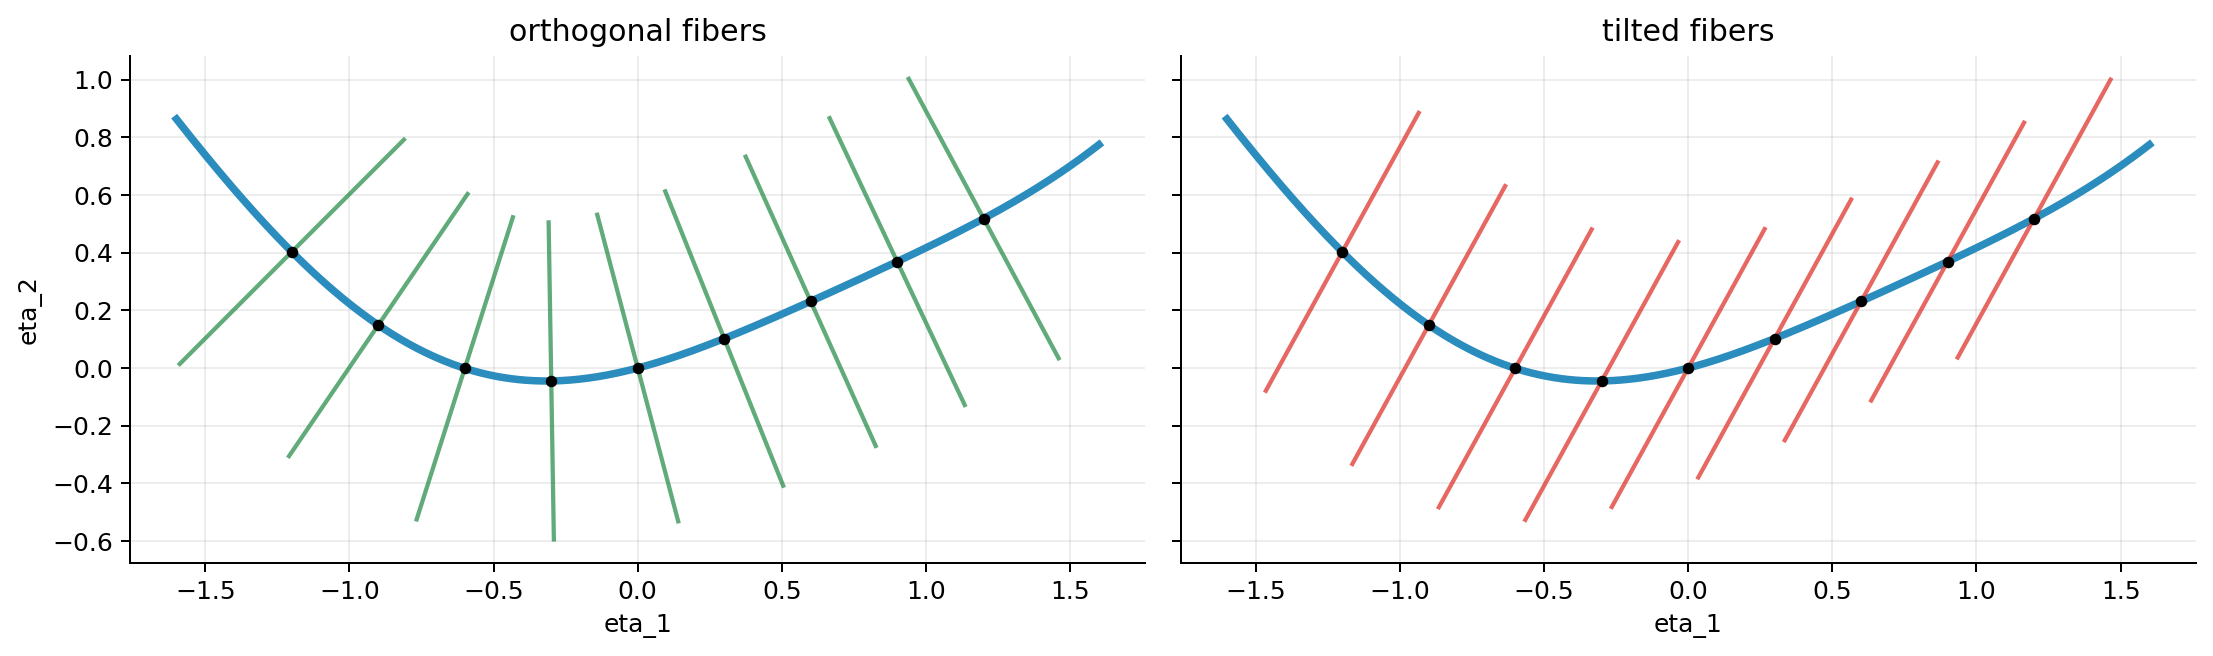

In [5]:
fiber_us = np.linspace(-1.2, 1.2, 9)
tilt = np.array([0.55, 1.0])
tilt = tilt / np.linalg.norm(tilt)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2), sharex=True, sharey=True)
for ax, mode in zip(axes, ['orthogonal fibers', 'tilted fibers']) :
    ax.plot(curve_pts[:, 0], curve_pts[:, 1], color='#2b8cbe', lw=3)
    for u in fiber_us:
        p = eta_curve(u)
        if mode.startswith('orthogonal'):
            direction = unit_normal(u)
            color = '#238b45'
        else:
            direction = tilt
            color = '#de2d26'
        seg = np.array([p - 0.55*direction, p + 0.55*direction])
        ax.plot(seg[:, 0], seg[:, 1], color=color, alpha=0.72, lw=1.7)
        ax.scatter([p[0]], [p[1]], color='black', s=13, zorder=3)
    ax.set_title(mode)
    ax.set_xlabel('eta_1')
    ax.set_aspect('equal', adjustable='box')
axes[0].set_ylabel('eta_2')
fibers_path = FIG_DIR / 'ancillary_fiber_foliations.png'
savefig(fibers_path)
display_artifact(fibers_path)


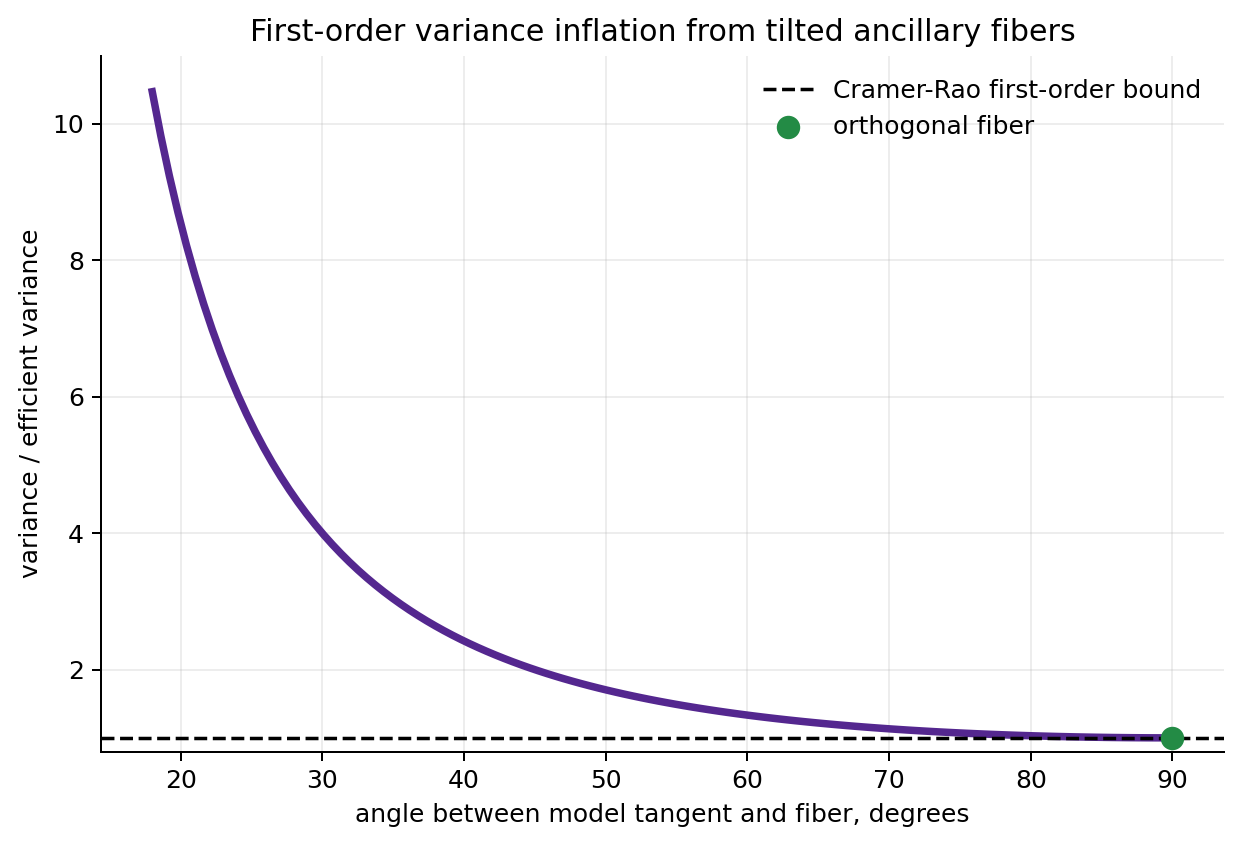

In [6]:
def variance_factor(u, fiber_direction):
    t = tangent(u)
    r = np.asarray(fiber_direction, dtype=float)
    cross = abs(t[0]*r[1] - t[1]*r[0])
    return float(np.dot(r, r) / (cross**2))

def cr_factor(u):
    t = tangent(u)
    return float(1.0 / np.dot(t, t))

angle_degrees = np.linspace(18, 90, 120)
selected_u = 0.55
t = tangent(selected_u)
t_angle = math.atan2(t[1], t[0])
ratios = []
for deg in angle_degrees:
    direction_angle = t_angle + math.radians(deg)
    r = np.array([math.cos(direction_angle), math.sin(direction_angle)])
    ratios.append(variance_factor(selected_u, r) / cr_factor(selected_u))

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(angle_degrees, ratios, color='#54278f', lw=3)
ax.axhline(1.0, color='black', lw=1.4, ls='--', label='Cramer-Rao first-order bound')
ax.scatter([90], [1], color='#238b45', s=70, zorder=3, label='orthogonal fiber')
ax.set_title('First-order variance inflation from tilted ancillary fibers')
ax.set_xlabel('angle between model tangent and fiber, degrees')
ax.set_ylabel('variance / efficient variance')
ax.set_ylim(0.8, max(ratios)*1.05)
ax.legend(frameon=False)
efficiency_path = FIG_DIR / 'fisher_efficiency_angle_inflation.png'
savefig(efficiency_path)
display_artifact(efficiency_path)


## 5. Interactive View: A Local `(u, v)` Coordinate Sheet

The next artifact turns the fibers into a small ruled sheet. The blue curve is the statistical model `S`; the translucent sheet is a neighborhood of ambient observations coordinatized by `(u, v)`. Sliding in `v` keeps the estimate fixed, while sliding in `u` changes the reported parameter.


In [ ]:
U = np.linspace(-1.35, 1.35, 90)
V = np.linspace(-0.45, 0.45, 21)
X = np.zeros((len(V), len(U)))
Y = np.zeros_like(X)
Z = np.zeros_like(X)
for j, u in enumerate(U):
    p = eta_curve(u)
    n = unit_normal(u)
    for i, v in enumerate(V):
        q = p + v*n
        X[i, j] = q[0]
        Y[i, j] = q[1]
        Z[i, j] = v
curve = eta_curve(U)
fig = go.Figure()
fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Viridis', opacity=0.70, showscale=False,
                         hovertemplate='eta1=%{x:.3f}<br>eta2=%{y:.3f}<br>fiber v=%{z:.3f}<extra></extra>'))
fig.add_trace(go.Scatter3d(x=curve[:,0], y=curve[:,1], z=np.zeros_like(U), mode='lines',
                           line=dict(color='black', width=7), name='model S: v=0'))
fig.update_layout(title='Ancillary fiber coordinates around a curved exponential family',
                  scene=dict(xaxis_title='eta_1', yaxis_title='eta_2', zaxis_title='fiber coordinate v'),
                  width=850, height=650, margin=dict(l=0, r=0, t=55, b=0))
fiber_sheet_html = HTML_DIR / 'ancillary_fiber_coordinate_sheet.html'
fig.write_html(fiber_sheet_html, include_plotlyjs=True)
display_artifact(fiber_sheet_html, 'html')


## 6. Higher-Order Terms: Curvature Is What Remains After the Tangent Approximation

First-order asymptotics only sees the tangent line or tangent plane. Higher-order asymptotics asks what changes when the model bends and when the ancillary fibers themselves bend. In the chapter's decomposition, one term belongs to the curved model, another to the coordinate choice on the model, and the estimator-dependent term belongs to the curvature of the ancillary family.

For a planar curve, the scalar curvature below is not the full tensor formula from the book, but it is a faithful computational proxy for the lesson: when the embedded family is nearly straight, the tangent approximation is excellent; where the curve bends, second-order distinctions become visible.


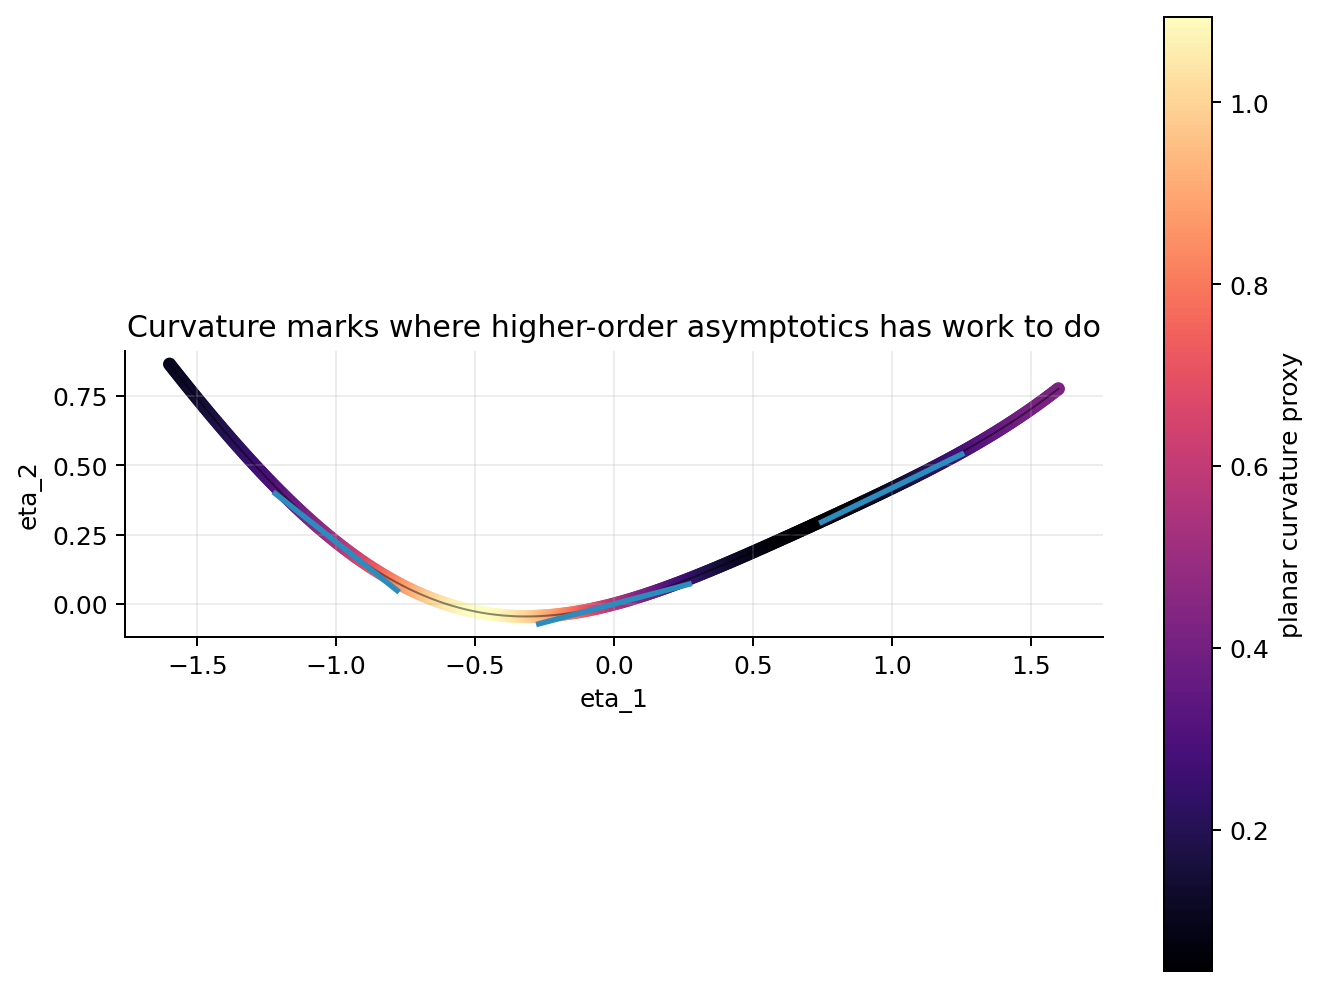

In [8]:
def curve_derivatives(u):
    dy = 0.64*u + 0.264*np.cos(2.2*u)
    ddy = 0.64 - 0.5808*np.sin(2.2*u)
    return dy, ddy

curv_u = np.linspace(-1.6, 1.6, 500)
dy, ddy = curve_derivatives(curv_u)
curvature = np.abs(ddy) / (1 + dy**2)**1.5
curv_pts = eta_curve(curv_u)
fig, ax = plt.subplots(figsize=(7.6, 5.6))
sc = ax.scatter(curv_pts[:,0], curv_pts[:,1], c=curvature, s=18, cmap='magma', label='curvature along S')
ax.plot(curv_pts[:,0], curv_pts[:,1], color='black', lw=0.8, alpha=0.45)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('planar curvature proxy')
for u in [-1.0, 0.0, 1.0]:
    p = eta_curve(u)
    t = tangent(u); t = t / np.linalg.norm(t)
    seg = np.array([p - 0.28*t, p + 0.28*t])
    ax.plot(seg[:,0], seg[:,1], color='#2b8cbe', lw=2.2)
ax.set_title('Curvature marks where higher-order asymptotics has work to do')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_aspect('equal', adjustable='box')
curvature_path = FIG_DIR / 'curved_family_curvature_proxy.png'
savefig(curvature_path)
display_artifact(curvature_path)


## 7. Applied Lab: Compare Orthogonal and Tilted Estimators

The lab simulates ambient observed points around a true point on the curved family. Two estimators are compared:

- **Orthogonal estimator:** project each point to the nearest point on `S`, a local stand-in for MLE projection.
- **Tilted-fiber estimator:** assign the point to the curve point whose tilted fiber passes closest to the observation.

Both estimators are consistent in this local experiment. The tilted one is worse at first order because its fibers are not orthogonal to the model tangent.


In [9]:
def estimate_tilted(point, grid, direction):
    pts = eta_curve(grid)
    r = np.asarray(direction, dtype=float)
    r = r / np.linalg.norm(r)
    residual = pts - point
    perpendicular = residual[:,0]*(-r[1]) + residual[:,1]*r[0]
    return float(grid[int(np.argmin(perpendicular**2))])

sim_grid = np.linspace(-1.3, 1.3, 1801)
lab_rows = []
true_u = 0.55
true_eta = eta_curve(true_u)
ambient_cov = np.array([[1.0, 0.0], [0.0, 1.0]])
tilt_direction = np.array([math.cos(t_angle + math.radians(45)), math.sin(t_angle + math.radians(45))])
for N in [40, 120, 360, 1080]:
    obs = rng.multivariate_normal(true_eta, ambient_cov / N, size=1600)
    orth = np.array([project_to_curve(p, sim_grid)[0] for p in obs])
    tilted = np.array([estimate_tilted(p, sim_grid, tilt_direction) for p in obs])
    efficient_theory = cr_factor(true_u) / N
    tilted_theory = variance_factor(true_u, tilt_direction) / N
    lab_rows.append({
        'N': N,
        'orthogonal_bias': float(orth.mean() - true_u),
        'tilted_bias': float(tilted.mean() - true_u),
        'orthogonal_variance': float(orth.var(ddof=1)),
        'tilted_variance': float(tilted.var(ddof=1)),
        'efficient_theory_variance': float(efficient_theory),
        'tilted_theory_variance': float(tilted_theory),
        'tilted_to_orthogonal_variance_ratio': float(tilted.var(ddof=1) / orth.var(ddof=1)),
    })
lab_table = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / 'orthogonal_vs_tilted_estimator_lab.csv'
lab_table.to_csv(lab_path, index=False)
display_artifact(lab_path)


,N,orthogonal_bias,tilted_bias,orthogonal_variance,tilted_variance,efficient_theory_variance,tilted_theory_variance,tilted_to_orthogonal_variance_ratio
0,40,0.001956,0.004508,0.020779,0.042145,0.020865,0.041729,2.028271
1,120,-0.000273,-0.004019,0.006627,0.013177,0.006955,0.013910,1.988350
2,360,-0.002605,-0.003968,0.002252,0.004525,0.002318,0.004637,2.008784
3,1080,0.002170,0.003010,0.000748,0.001508,0.000773,0.001546,2.017565


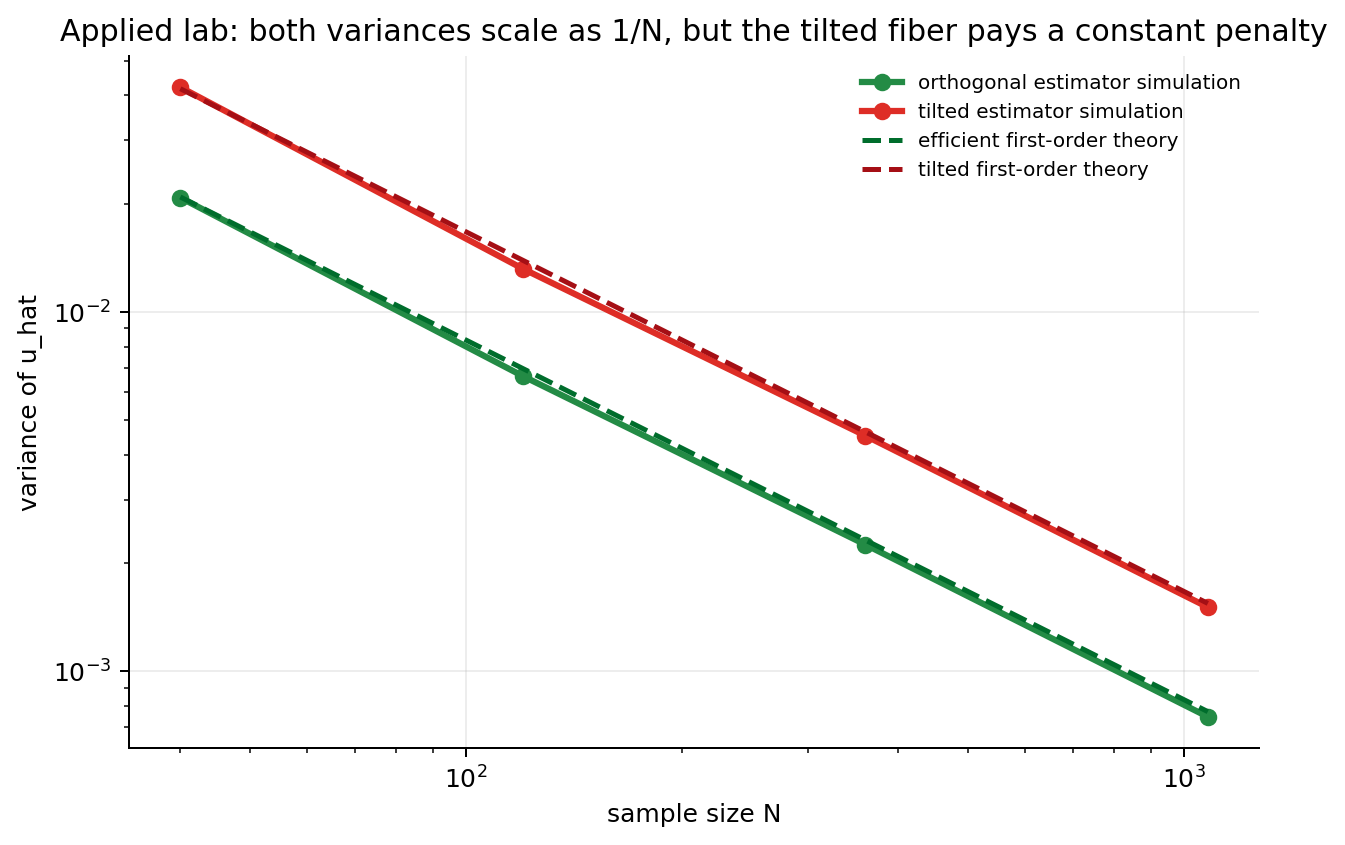

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(lab_table['N'], lab_table['orthogonal_variance'], marker='o', lw=2.5, label='orthogonal estimator simulation', color='#238b45')
ax.plot(lab_table['N'], lab_table['tilted_variance'], marker='o', lw=2.5, label='tilted estimator simulation', color='#de2d26')
ax.plot(lab_table['N'], lab_table['efficient_theory_variance'], ls='--', lw=2, color='#006d2c', label='efficient first-order theory')
ax.plot(lab_table['N'], lab_table['tilted_theory_variance'], ls='--', lw=2, color='#a50f15', label='tilted first-order theory')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Applied lab: both variances scale as 1/N, but the tilted fiber pays a constant penalty')
ax.set_xlabel('sample size N')
ax.set_ylabel('variance of u_hat')
ax.legend(frameon=False, fontsize=8)
lab_variance_path = FIG_DIR / 'applied_lab_variance_scaling.png'
savefig(lab_variance_path)
display_artifact(lab_variance_path)


## 8. Hypothesis Testing: Boundaries Are Ancillary Fibers Too

A large-sample test can also be drawn as a geometric object. Under a null value `u0`, the observed point should be near `eta(u0)`. A rejection region is separated from the acceptance region by a boundary surface. As `N` grows, that boundary approaches the null point. Treating `u0` as variable turns the family of test boundaries into another ancillary family.

This is why estimation and testing share the same first-order geometry. A first-order efficient test has a boundary that becomes orthogonal to the model at the null point. Different classical tests can agree to first order while differing in second-order power because their boundaries have different curvature or slightly different asymptotic angles.


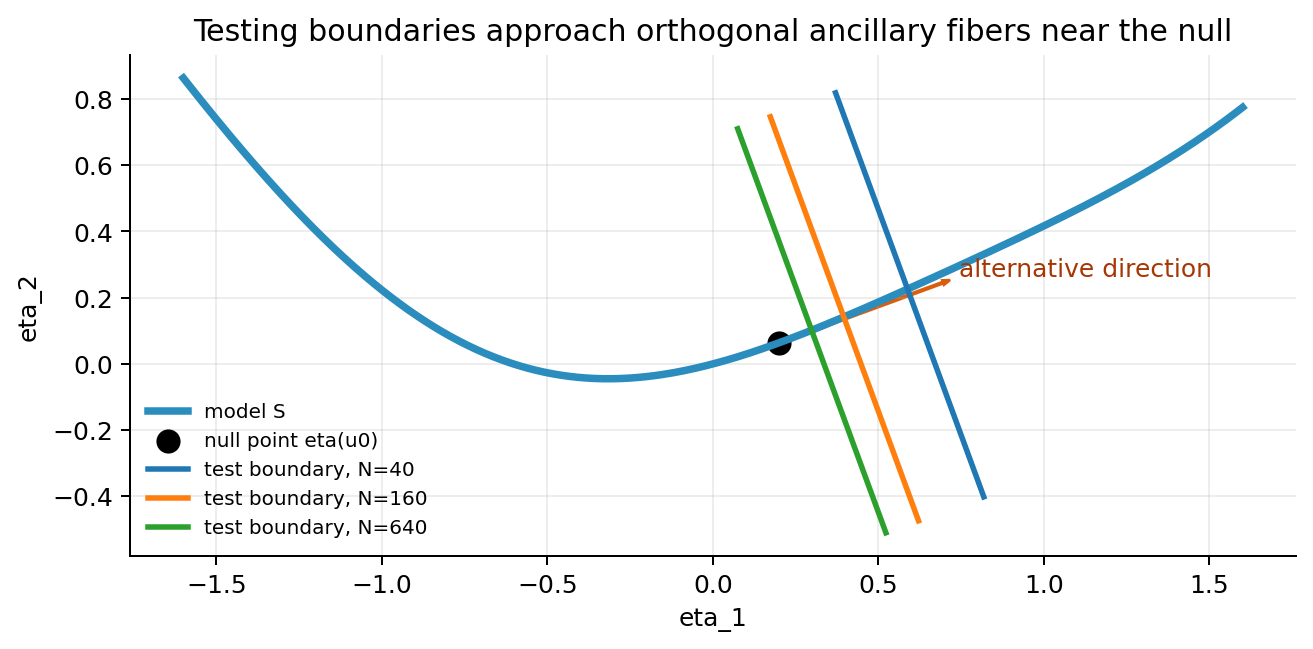

In [11]:
u0 = 0.2
p0 = eta_curve(u0)
n0 = unit_normal(u0)
t0 = tangent(u0); t0 = t0 / np.linalg.norm(t0)
thresholds = {40: 0.42, 160: 0.21, 640: 0.105}
fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.plot(curve_pts[:,0], curve_pts[:,1], color='#2b8cbe', lw=3, label='model S')
ax.scatter([p0[0]], [p0[1]], s=75, color='black', label='null point eta(u0)')
for N, offset in thresholds.items():
    center = p0 + offset*t0
    boundary = np.array([center - 0.65*n0, center + 0.65*n0])
    ax.plot(boundary[:,0], boundary[:,1], lw=2.2, label=f'test boundary, N={N}')
ax.arrow(p0[0], p0[1], 0.55*t0[0], 0.55*t0[1], width=0.005, color='#d95f0e', length_includes_head=True)
ax.text(*(p0 + 0.58*t0), 'alternative direction', color='#a63603')
ax.set_title('Testing boundaries approach orthogonal ancillary fibers near the null')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_aspect('equal', adjustable='box')
ax.legend(frameon=False, fontsize=8)
testing_path = FIG_DIR / 'hypothesis_testing_boundaries.png'
savefig(testing_path)
display_artifact(testing_path)


## 9. Sanity Checks

The checks below are deliberately concrete. They verify the variance-angle identity used in the efficiency plot, confirm that the projection residual is nearly orthogonal to the curve tangent, check the simulated variance trend, and assert that all generated artifacts exist with nonzero size.


In [12]:
artifact_paths = [
    translation_path,
    projection_cloud_path,
    curved_projection_path,
    fibers_path,
    efficiency_path,
    fiber_sheet_html,
    curvature_path,
    lab_path,
    lab_variance_path,
    testing_path,
]

projection_residual = observed_point - eta_mle
projection_tangent = tangent(u_mle)
projection_orthogonality = float(abs(np.dot(projection_residual, projection_tangent)) / (np.linalg.norm(projection_residual) * np.linalg.norm(projection_tangent)))
ratio_at_90 = variance_factor(selected_u, unit_normal(selected_u)) / cr_factor(selected_u)
variance_monotone = bool(np.all(np.diff(lab_table['orthogonal_variance'].to_numpy()) < 0) and np.all(np.diff(lab_table['tilted_variance'].to_numpy()) < 0))
artifact_sizes = {str(p): Path(p).stat().st_size for p in artifact_paths}

checks = {
    'projection_residual_cosine_with_tangent': projection_orthogonality,
    'orthogonal_variance_ratio_should_be_one': float(ratio_at_90),
    'lab_variances_decrease_with_N': variance_monotone,
    'tilted_ratio_last_N': float(lab_table['tilted_to_orthogonal_variance_ratio'].iloc[-1]),
    'artifact_count': len(artifact_paths),
    'artifact_sizes': artifact_sizes,
}

assert projection_orthogonality < 0.015, projection_orthogonality
assert abs(ratio_at_90 - 1.0) < 1e-10, ratio_at_90
assert variance_monotone
assert lab_table['tilted_to_orthogonal_variance_ratio'].iloc[-1] > 1.45
assert all(size > 500 for size in artifact_sizes.values())

sanity_path = CHECK_DIR / 'chapter_07_sanity.json'
sanity_path.write_text(json.dumps(checks, indent=2), encoding='utf-8')
display_artifact(sanity_path)
checks


`artifacts/chapter-07/checks/chapter_07_sanity.json`

{'projection_residual_cosine_with_tangent': 0.0018781282408870286,
 'orthogonal_variance_ratio_should_be_one': 0.9999999999999996,
 'lab_variances_decrease_with_N': True,
 'tilted_ratio_last_N': 2.0175648408741043,
 'artifact_count': 10,
 'artifact_sizes': {'artifacts//chapter-07//tables//asymptotic_geometry_translation.csv': 566,
  'artifacts//chapter-07//figures//mle_observed_point_cloud.png': 209644,
  'artifacts//chapter-07//figures//curved_family_mle_projection.png': 83276,
  'artifacts//chapter-07//figures//ancillary_fiber_foliations.png': 136629,
  'artifacts//chapter-07//figures//fisher_efficiency_angle_inflation.png': 68942,
  'artifacts//chapter-07//html//ancillary_fiber_coordinate_sheet.html': 87410,
  'artifacts//chapter-07//figures//curved_family_curvature_proxy.png': 79063,
  'artifacts//chapter-07//tables//orthogonal_vs_tilted_estimator_lab.csv': 762,
  'artifacts//chapter-07//figures//applied_lab_variance_scaling.png': 92722,
  'artifacts//chapter-07//figures//hypothesi

## 10. Takeaways

- In a full exponential family, the MLE is especially transparent in expectation coordinates: match the observed sufficient statistic.
- In a curved exponential family, the observed point usually lands off the model, so an estimator is a geometric return map from the ambient family to the curved submanifold.
- The inverse images of that return map are ancillary fibers. They are not decoration; they encode the estimator.
- Consistency requires fibers to pass through the model point. First-order Fisher efficiency requires those fibers to be orthogonal to the model in the Fisher metric.
- Higher-order asymptotics begins where the tangent approximation stops. Curvature of the model, parameterization, and ancillary fibers explains why first-order efficient estimators can still differ.
- Large-sample hypothesis tests reuse the same geometry: moving rejection boundaries form ancillary hypersurfaces whose angle and curvature control power beyond first order.


## Course Standard Note

**Source span:** printed pages 165-177; PDF pages 173-185. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-07` using the chapter's local sanity JSON naming convention.
